#To understand and implement region-based image segmentation techniques including Region Growing, Region Splitting, and Region Merging for extracting meaningful regions from an image.




#Region Growing

**We start from a seed point. Then we check 8-neighbour pixels.
If neighbour intensity difference with seed is less than threshold,
we add it to region. This continues until no new pixels satisfy condition.**

#Region Splitting
**We check if entire image is homogeneous using standard deviation.
If not homogeneous, we divide into 4 parts.
This recursive division continues until each block becomes uniform**

#Region Merging

**We smooth image using Gaussian blur and calculate difference.
Regions with small difference are grouped together**

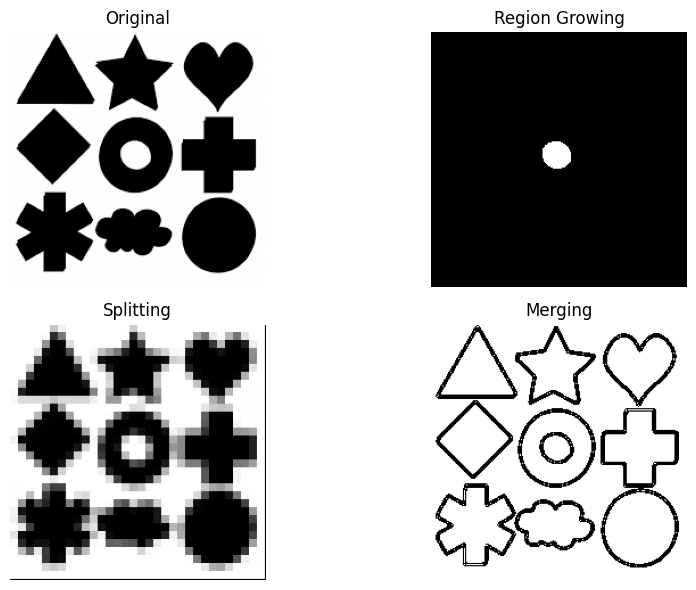

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------- LOAD IMAGE ----------
path = "CV_lab3.png"
img = cv2.imread(path, 0)       # load as grayscale

# ---------- REGION GROWING ----------
def region_growing(image, seed, threshold=10):
    h, w = image.shape
    segmented = np.zeros((h, w), np.uint8)
    stack = [seed]
    seed_value = image[seed]

    while stack:
        x, y = stack.pop()

        if segmented[x, y] == 0:
            segmented[x, y] = 255

            for dx in [-1,0,1]:
                for dy in [-1,0,1]:
                    nx, ny = x+dx, y+dy
                    if 0 <= nx < h and 0 <= ny < w:
                        if abs(int(image[nx, ny]) - int(seed_value)) < threshold:
                            stack.append((nx, ny))
    return segmented

# seed point (center pixel)
seed = (img.shape[0]//2, img.shape[1]//2)
rg_result = region_growing(img, seed)

# ---------- REGION SPLITTING ----------
def split(image, threshold=15):
    h, w = image.shape
    result = np.zeros_like(image)

    def recursive(x, y, h, w):
        region = image[x:x+h, y:y+w]
        if h < 8 or w < 8 or np.std(region) < threshold:
            result[x:x+h, y:y+w] = np.mean(region)
        else:
            recursive(x, y, h//2, w//2)
            recursive(x+h//2, y, h//2, w//2)
            recursive(x, y+w//2, h//2, w//2)
            recursive(x+h//2, y+w//2, h//2, w//2)

    recursive(0,0,h,w)
    return result

split_result = split(img)

# ---------- REGION MERGING ----------
def merge(image, threshold=10):
    blurred = cv2.GaussianBlur(image,(5,5),0)
    diff = cv2.absdiff(image, blurred)
    _, merged = cv2.threshold(diff, threshold, 255, cv2.THRESH_BINARY_INV)   #difference-based segmentation
    return merged

merge_result = merge(img)

# ---------- DISPLAY ----------
titles = ["Original", "Region Growing", "Splitting", "Merging"]
images = [img, rg_result, split_result, merge_result]

plt.figure(figsize=(10,6))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


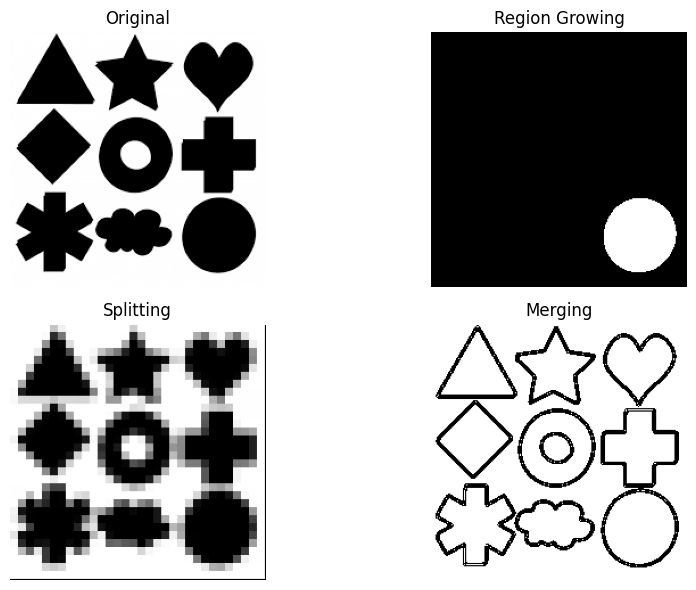

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------- LOAD IMAGE ----------
path = "CV_lab3.png"
img = cv2.imread(path, 0)       # load as grayscale

# ---------- REGION GROWING ----------
def region_growing(image, seed, threshold=10):
    h, w = image.shape
    segmented = np.zeros((h, w), np.uint8)
    stack = [seed]
    seed_value = image[seed]

    while stack:
        x, y = stack.pop()

        if segmented[x, y] == 0:
            segmented[x, y] = 255

            for dx in [-1,0,1]:
                for dy in [-1,0,1]:
                    nx, ny = x+dx, y+dy
                    if 0 <= nx < h and 0 <= ny < w:
                        if abs(int(image[nx, ny]) - int(seed_value)) < threshold:
                            stack.append((nx, ny))
    return segmented

# seed point (center pixel)
#seed = (img.shape[0]//2, img.shape[1]//2)
seed = (200,200)      # pick a point inside a shape
threshold = 100

rg_result = region_growing(img, seed)

# ---------- REGION SPLITTING ----------
def split(image, threshold=15):
    h, w = image.shape
    result = np.zeros_like(image)

    def recursive(x, y, h, w):
        region = image[x:x+h, y:y+w]
        if h < 8 or w < 8 or np.std(region) < threshold:
            result[x:x+h, y:y+w] = np.mean(region)
        else:
            recursive(x, y, h//2, w//2)
            recursive(x+h//2, y, h//2, w//2)
            recursive(x, y+w//2, h//2, w//2)
            recursive(x+h//2, y+w//2, h//2, w//2)

    recursive(0,0,h,w)
    return result

split_result = split(img)

# ---------- REGION MERGING ----------
def merge(image, threshold=10):
    blurred = cv2.GaussianBlur(image,(5,5),0)
    diff = cv2.absdiff(image, blurred)
    _, merged = cv2.threshold(diff, threshold, 255, cv2.THRESH_BINARY_INV)
    return merged

merge_result = merge(img)

# ---------- DISPLAY ----------
titles = ["Original", "Region Growing", "Splitting", "Merging"]
images = [img, rg_result, split_result, merge_result]

plt.figure(figsize=(10,6))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


/tmp/ipython-input-1944457145.py:10: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(),256,[0,256])


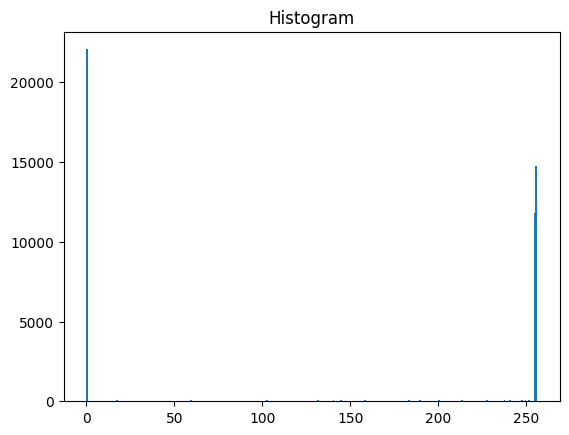

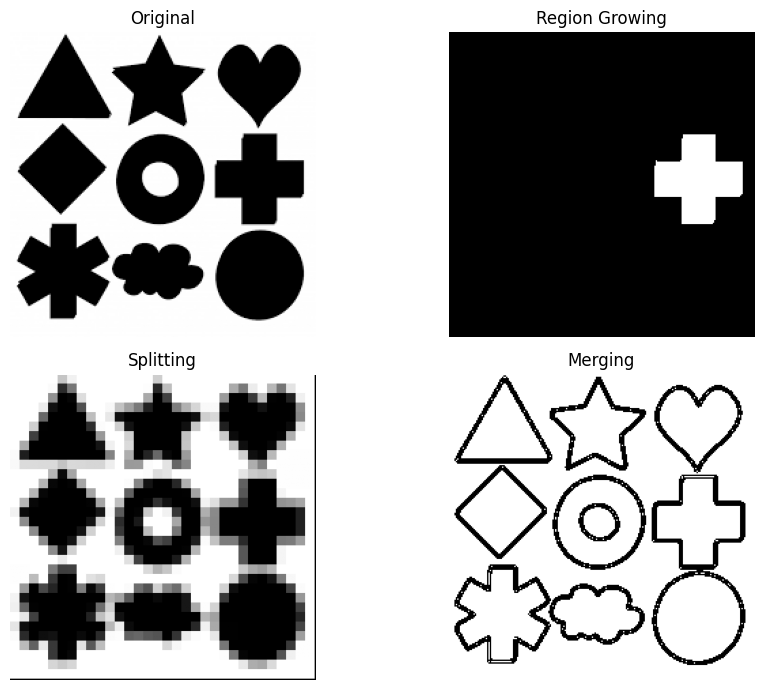

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ================= LOAD IMAGE =================
path = "CV_lab3.png"
img = cv2.imread(path,0)

# ================= HISTOGRAM =================
plt.hist(img.ravel(),256,[0,256])
plt.title("Histogram")
plt.show()

# ================= OTSU THRESHOLD =================
otsu_value, _ = cv2.threshold(img,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)  # automatically try all 0 to 255
threshold = int(otsu_value * 0.25) #Only pixels very close to seed intensity will grow

# ================= REGION GROWING =================
def region_growing(image, seed, threshold):
    h, w = image.shape
    segmented = np.zeros((h,w), np.uint8)
    stack = [seed]
    seed_val = image[seed]

    while stack:
        x,y = stack.pop()

        if segmented[x,y] == 0:
            segmented[x,y] = 255

            for dx in [-1,0,1]:
                for dy in [-1,0,1]:
                    nx, ny = x+dx, y+dy
                    if 0 <= nx < h and 0 <= ny < w:
                        if abs(int(image[nx,ny]) - int(seed_val)) < threshold:
                            stack.append((nx,ny))
    return segmented
# Find foreground using Otsu
_, binary = cv2.threshold(img,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

# Get coordinates of foreground pixels
ys, xs = np.where(binary==255)

# choose middle foreground pixel as seed
seed = (ys[len(ys)//2], xs[len(xs)//2])
rg_result = region_growing(img, seed, threshold)


# ================= REGION SPLITTING =================
def split(image, thresh=15):
    h, w = image.shape
    result = np.zeros_like(image)

    def divide(x,y,h,w):
        region = image[x:x+h, y:y+w]
        if h<8 or w<8 or np.std(region)<thresh:
            result[x:x+h, y:y+w] = np.mean(region)
        else:
            divide(x,y,h//2,w//2)
            divide(x+h//2,y,h//2,w//2)
            divide(x,y+w//2,h//2,w//2)
            divide(x+h//2,y+w//2,h//2,w//2)

    divide(0,0,h,w)
    return result

split_result = split(img)

# ================= REGION MERGING =================
def merge(image, thresh=10):
    blur = cv2.GaussianBlur(image,(5,5),0)
    diff = cv2.absdiff(image, blur)
    _, merged = cv2.threshold(diff, thresh,255,cv2.THRESH_BINARY_INV)
    return merged

merge_result = merge(img)

# ================= DISPLAY =================
titles = ["Original","Region Growing","Splitting","Merging"]
images = [img, rg_result, split_result, merge_result]

plt.figure(figsize=(10,7))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


/tmp/ipython-input-2510949428.py:10: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(),256,[0,256])


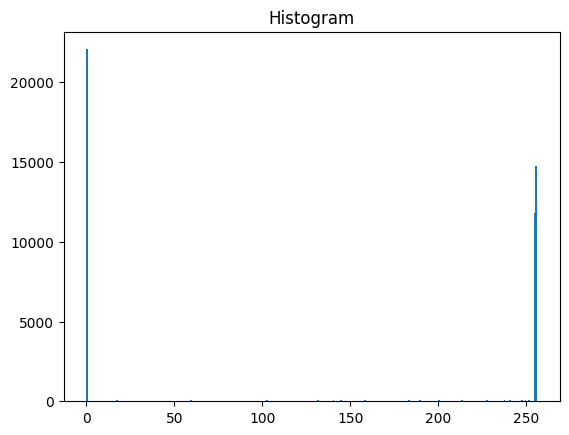

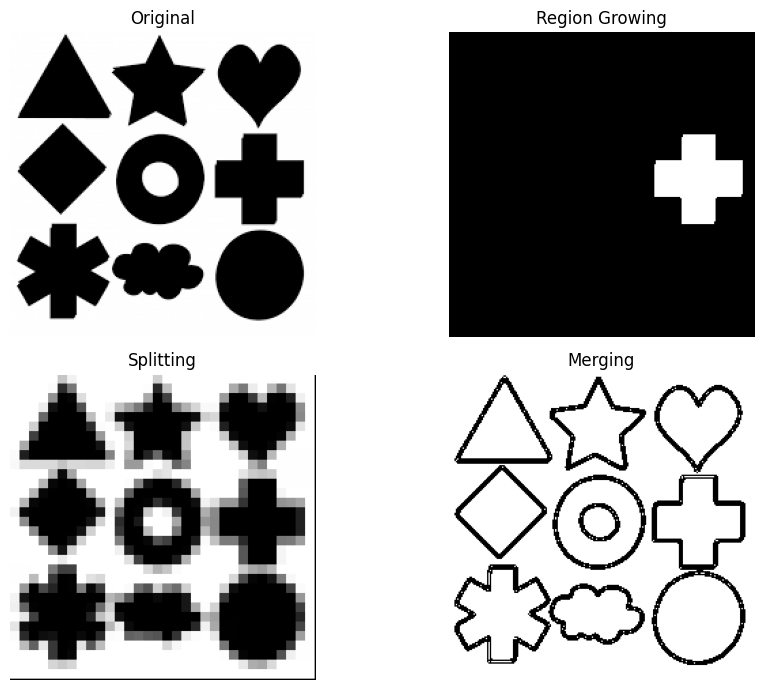

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ================= LOAD IMAGE =================
path = "CV_lab3.png"
img = cv2.imread(path,0)

# ================= HISTOGRAM =================
plt.hist(img.ravel(),256,[0,256])
plt.title("Histogram")
plt.show()

# ================= OTSU THRESHOLD =================
otsu_value, _ = cv2.threshold(img,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
threshold = int(otsu_value * 0.7)

# ================= REGION GROWING =================
def region_growing(image, seed, threshold):
    h, w = image.shape
    segmented = np.zeros((h,w), np.uint8)
    stack = [seed]
    seed_val = image[seed]

    while stack:
        x,y = stack.pop()

        if segmented[x,y] == 0:
            segmented[x,y] = 255

            for dx in [-1,0,1]:
                for dy in [-1,0,1]:
                    nx, ny = x+dx, y+dy
                    if 0 <= nx < h and 0 <= ny < w:
                        if abs(int(image[nx,ny]) - int(seed_val)) < threshold:
                            stack.append((nx,ny))
    return segmented
# Find foreground using Otsu
_, binary = cv2.threshold(img,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

# Get coordinates of foreground pixels
ys, xs = np.where(binary==255)

# choose middle foreground pixel as seed
seed = (ys[len(ys)//2], xs[len(xs)//2])
rg_result = region_growing(img, seed, threshold)


# ================= REGION SPLITTING =================
def split(image, thresh=15):
    h, w = image.shape
    result = np.zeros_like(image)

    def divide(x,y,h,w):
        region = image[x:x+h, y:y+w]
        if h<8 or w<8 or np.std(region)<thresh:
            result[x:x+h, y:y+w] = np.mean(region)
        else:
            divide(x,y,h//2,w//2)
            divide(x+h//2,y,h//2,w//2)
            divide(x,y+w//2,h//2,w//2)
            divide(x+h//2,y+w//2,h//2,w//2)

    divide(0,0,h,w)
    return result

split_result = split(img)

# ================= REGION MERGING =================
def merge(image, thresh=10):
    blur = cv2.GaussianBlur(image,(5,5),0)
    diff = cv2.absdiff(image, blur)
    _, merged = cv2.threshold(diff, thresh,255,cv2.THRESH_BINARY_INV)
    return merged

merge_result = merge(img)

# ================= DISPLAY =================
titles = ["Original","Region Growing","Splitting","Merging"]
images = [img, rg_result, split_result, merge_result]

plt.figure(figsize=(10,7))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


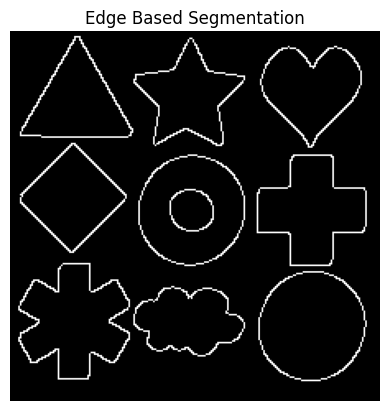

In [ ]:
#Edge based segmentation

img = cv2.imread("CV_lab3.png",0)

edges = cv2.Canny(img, 100, 200)

plt.imshow(edges, cmap='gray')
plt.title("Edge Based Segmentation")
plt.axis("off")
plt.show()


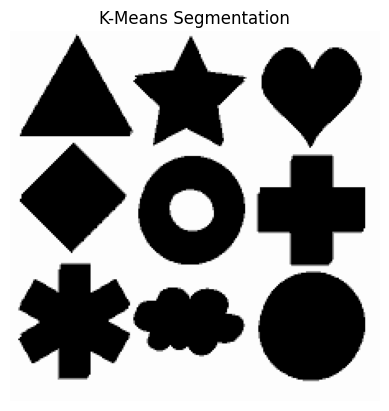

In [ ]:
#k means segementation
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("CV_lab3.png",0)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# reshape image to 2D array of pixels
pixel_values = img_rgb.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

# define criteria and K
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
k = 3

_, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

centers = np.uint8(centers)
segmented_data = centers[labels.flatten()]
segmented_image = segmented_data.reshape(img_rgb.shape)

plt.imshow(segmented_image)
plt.title("K-Means Segmentation")
plt.axis("off")
plt.show()


**Different seed points and thresholds**

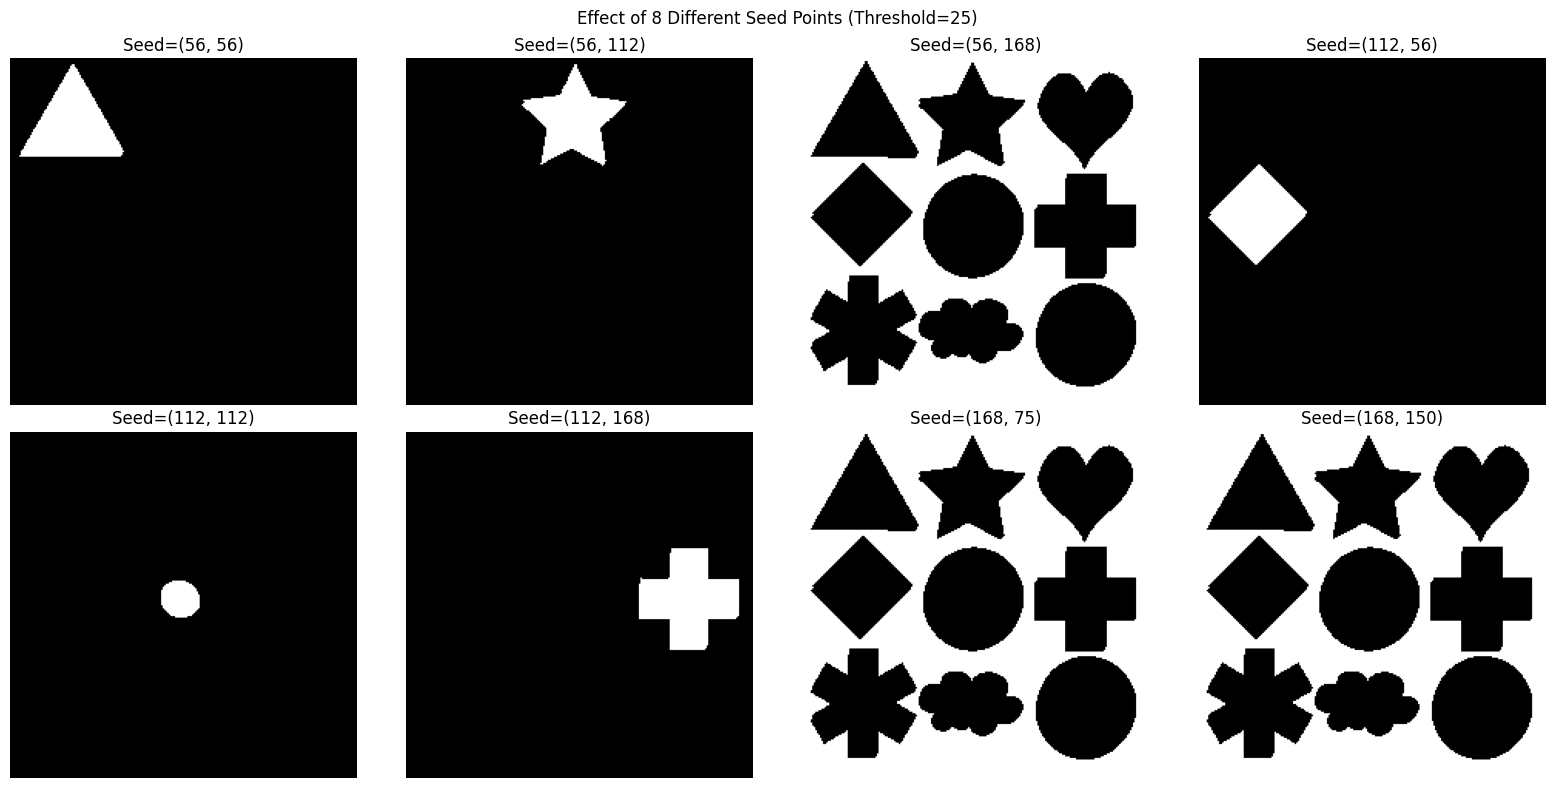

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread("CV_lab3.png", 0)

# Region Growing Function
def region_growing(image, seed, threshold):
    h, w = image.shape
    segmented = np.zeros((h,w), np.uint8)
    stack = [seed]
    seed_val = image[seed]

    while stack:
        x,y = stack.pop()

        if segmented[x,y] == 0:
            segmented[x,y] = 255

            for dx in [-1,0,1]:
                for dy in [-1,0,1]:
                    nx, ny = x+dx, y+dy
                    if 0 <= nx < h and 0 <= ny < w:
                        if segmented[nx,ny] == 0:
                            if abs(int(image[nx,ny]) - int(seed_val)) < threshold:
                                stack.append((nx,ny))
    return segmented


# ---------------- FIXED THRESHOLD ----------------
threshold = 25

# ---------------- 8 DIFFERENT SEED POINTS ----------------
h, w = img.shape
seed_points = [
    (h//4, w//4),
    (h//4, w//2),
    (h//4, 3*w//4),
    (h//2, w//4),
    (h//2, w//2),
    (h//2, 3*w//4),
    (3*h//4, w//3),
    (3*h//4, 2*w//3)
]

plt.figure(figsize=(16,8))

for i, seed in enumerate(seed_points):
    result = region_growing(img, seed, threshold)

    plt.subplot(2,4,i+1)
    plt.imshow(result, cmap="gray")
    plt.title(f"Seed={seed}")
    plt.axis("off")

plt.suptitle(f"Effect of 8 Different Seed Points (Threshold={threshold})")
plt.tight_layout()
plt.show()


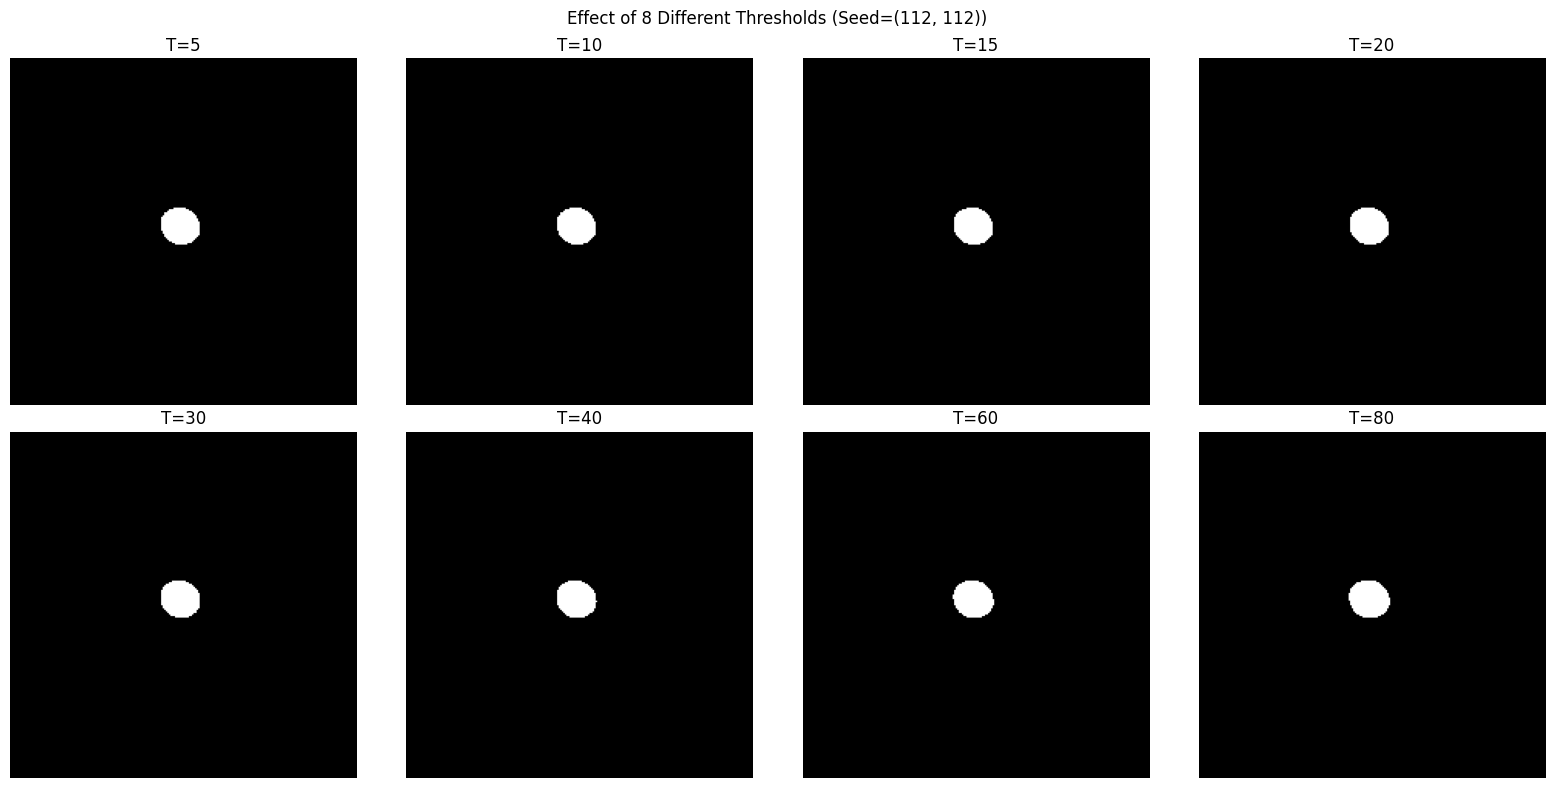

In [ ]:
# ---------------- FIXED SEED ----------------
h, w = img.shape
seed = (h//2, w//2)

# ---------------- 8 DIFFERENT THRESHOLDS ----------------
thresholds = [5, 10, 15, 20, 30, 40, 60, 80]

plt.figure(figsize=(16,8))

for i, thresh in enumerate(thresholds):
    result = region_growing(img, seed, thresh)

    plt.subplot(2,4,i+1)
    plt.imshow(result, cmap="gray")
    plt.title(f"T={thresh}")
    plt.axis("off")

plt.suptitle(f"Effect of 8 Different Thresholds (Seed={seed})")
plt.tight_layout()
plt.show()


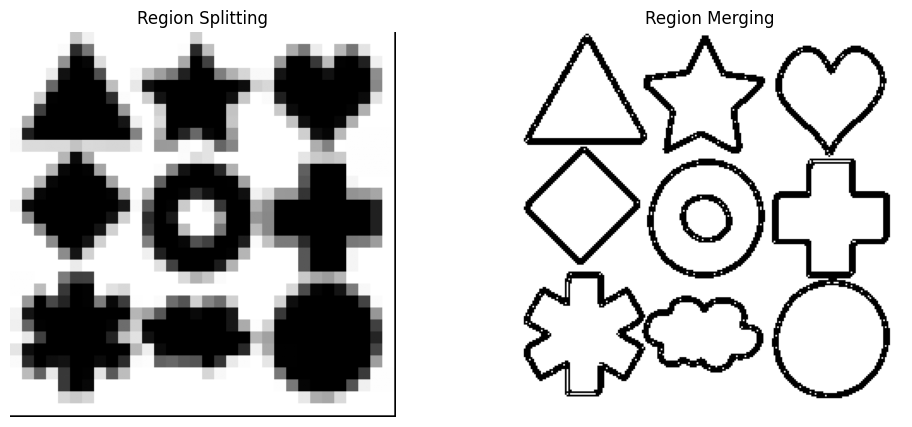

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(split_result, cmap="gray")
plt.title("Region Splitting")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(merge_result, cmap="gray")
plt.title("Region Merging")
plt.axis("off")

plt.show()
